# Dependencies importing

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
import custom_modules.PipeData as pidf

from IPython.display import display

In [ ]:
# paths for files with original data
PATH_TO_DATA = {
    'run_1': 
        ('data/Original data/Run1/run1_WM32_data.csv',
        'data/Original data/Run1/run1_WM32_defects.csv',
        'data/Original data/Run1/run1_WM32_pipe.csv'),
    'run_2':
        ('data/Original data/Run2/run2_WM32_data.csv',
        'data/Original data/Run2/run2_WM32_defects.csv',
        'data/Original data/Run2/run2_WM32_pipe.csv')
}

In [3]:
#constants for db connect
db_name = 'network_db'
pg_host = 'postgres_database'
sql_user = 'postgres'
sql_pwd = '12345'
port = '5432'
schema_name = 'public'

In [4]:
# sql insert query templates
INSERT_data_cell = """INSERT INTO input_data_cell(
                                    file_id, 
                                    row_id, 
                                    detector_id, 
                                    time_values, 
                                    amplitude_values,
                                    defect_state,
                                    defect_depth) VALUES (%s,%s,%s,%s,%s,%s,%s)"""

# Data reading

# Data preprocess

## Output ML model data preprocess

In [9]:
# defects depths mask creation from defects_df from data from data_df

# create base zeros dataframe with size like data_df
Y_df = pd.DataFrame(np.zeros((data_df.shape[0], data_df.shape[1])))

# read line-by-line defects_df
# get defects location and mark by ones
for row_name in defects_df.index.values.tolist():

    # get defect properties
    row_min = int(defects_df.loc[row_name].loc['row_min'])
    row_max = int(defects_df.loc[row_name].loc['row_max'])
    detector_min = int(defects_df.loc[row_name].loc['detector_min'])   
    detector_max = int(defects_df.loc[row_name].loc['detector_max'])
    defect_depth = defects_df.loc[row_name].loc['fea_depth']

    #defect_depth = 1
    
    # mark defect location in base dataframe
    if (detector_min < detector_max):
        Y_df.iloc[row_min:row_max+1,detector_min:detector_max+1] = defect_depth
        continue

    Y_df.iloc[row_min:row_max+1,detector_min:data_df.shape[1]] = defect_depth
    Y_df.iloc[row_min:row_max+1,0:detector_max+1] = defect_depth

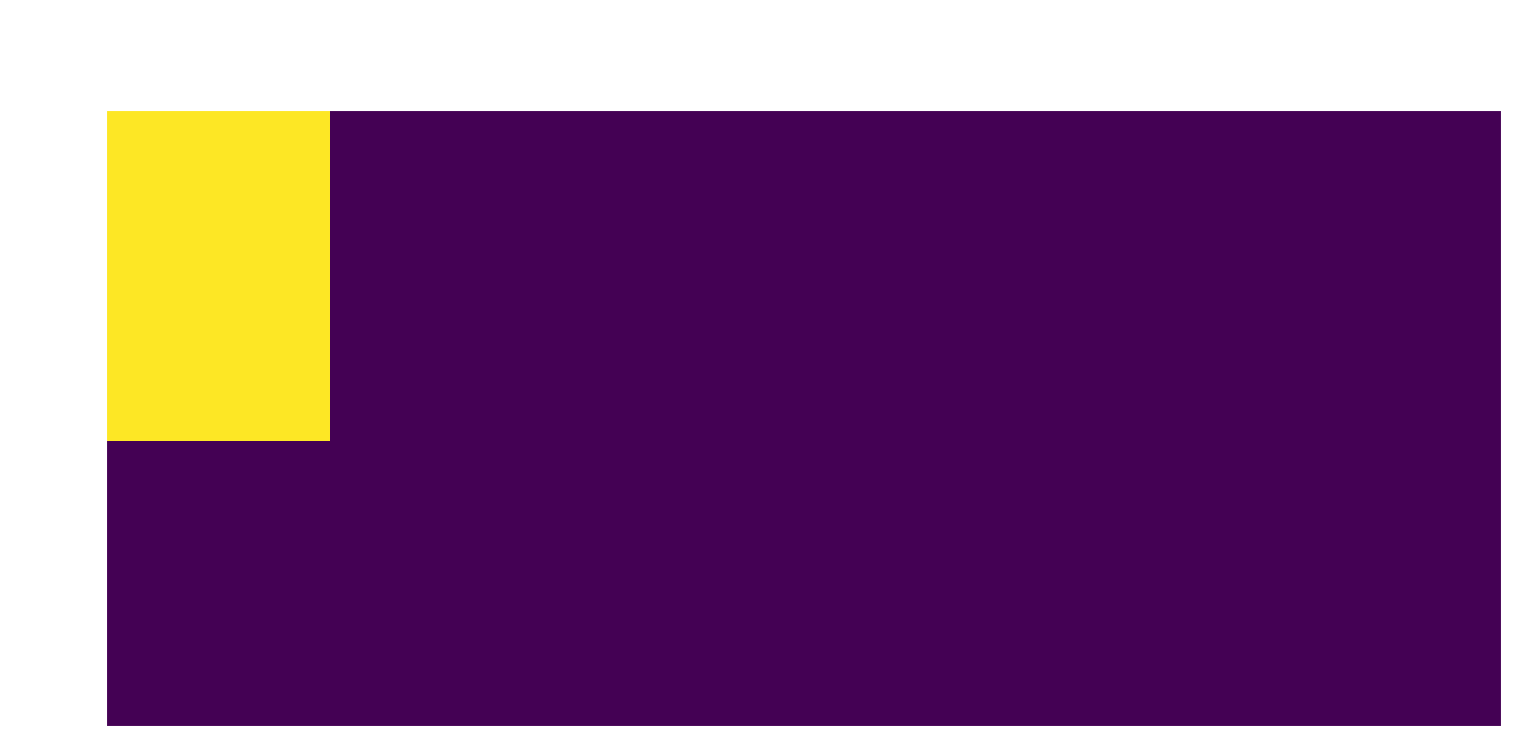

In [13]:
# defects depths mask creation from defects_df from data from data_df

# create base zeros dataframe with size like data_df
# crop_size_df = pd.DataFrame(np.zeros((data_df.shape[0], data_df.shape[1])))
# crop_size_df.iloc[0:64,0:64] = 1

# data_matrix = crop_size_df.to_numpy()
# title = 'Размер одного кропа' 
# xlabel = 'Номер датчика'
# ylabel = 'Номер измерения'

# with plt.style.context('dark_background'):
#        fig, ax = plt.subplots()
#        
#        fig.set_figwidth(18)
#        fig.set_figheight(8)
#
#        ax.pcolormesh(data_matrix)
#
#        ax.invert_yaxis()
#    
#        ax.set_title(title, fontsize=25) 
#        ax.set_xlabel(xlabel, fontsize=20) 
#        ax.set_ylabel(ylabel, fontsize=20) 
#    
#        fig.patch.set_alpha(0.0)
#          
#        ax.tick_params(axis='both', which='both', labelsize = 20)
#        
#        ax.xaxis.tick_top()
#        ax.xaxis.set_label_position('top')
#        
#plt.show()

In [10]:
#np_Y_df = Y_df.to_numpy()
#shift_num = int(np_Y_df.shape[1]/2)
#arr = np.roll(np_Y_df,shift_num,axis=1)

In [11]:
'''with plt.style.context('dark_background'):
    fig, ax = plt.subplots()
    
    fig.set_figwidth(18)
    fig.set_figheight(8)
    
    ax.pcolormesh(arr)
    
    ax.invert_yaxis()

    ax.set_title('Развернутая карта дефектов файл 2', fontsize=25) 
    ax.set_xlabel('Номер датчика', fontsize=20) 
    ax.set_ylabel('Номер измерения', fontsize=20) 

    fig.patch.set_alpha(0.0)
      
    ax.tick_params(axis='both', which='both', labelsize = 20)

    ax.set_xticks(np.arange(0,arr.shape[1]+1,40))
    ax.set_yticks(np.arange(0,arr.shape[0]+1,16))

    # 0 40 80 120 160 200 240 280 320 360 400

    ax.set_xticklabels(np.concatenate(
                        [np.arange(shift_num,arr.shape[1]+1,40),
                        np.arange(0,shift_num,40)],axis=0))
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
plt.show()'''

"with plt.style.context('dark_background'):\n    fig, ax = plt.subplots()\n    \n    fig.set_figwidth(18)\n    fig.set_figheight(8)\n    \n    ax.pcolormesh(arr)\n    \n    ax.invert_yaxis()\n\n    ax.set_title('Развернутая карта дефектов файл 2', fontsize=25) \n    ax.set_xlabel('Номер датчика', fontsize=20) \n    ax.set_ylabel('Номер измерения', fontsize=20) \n\n    fig.patch.set_alpha(0.0)\n      \n    ax.tick_params(axis='both', which='both', labelsize = 20)\n\n    ax.set_xticks(np.arange(0,arr.shape[1]+1,40))\n    ax.set_yticks(np.arange(0,arr.shape[0]+1,16))\n\n    # 0 40 80 120 160 200 240 280 320 360 400\n\n    ax.set_xticklabels(np.concatenate(\n                        [np.arange(shift_num,arr.shape[1]+1,40),\n                        np.arange(0,shift_num,40)],axis=0))\n    ax.xaxis.tick_top()\n    ax.xaxis.set_label_position('top')\n    \nplt.show()"

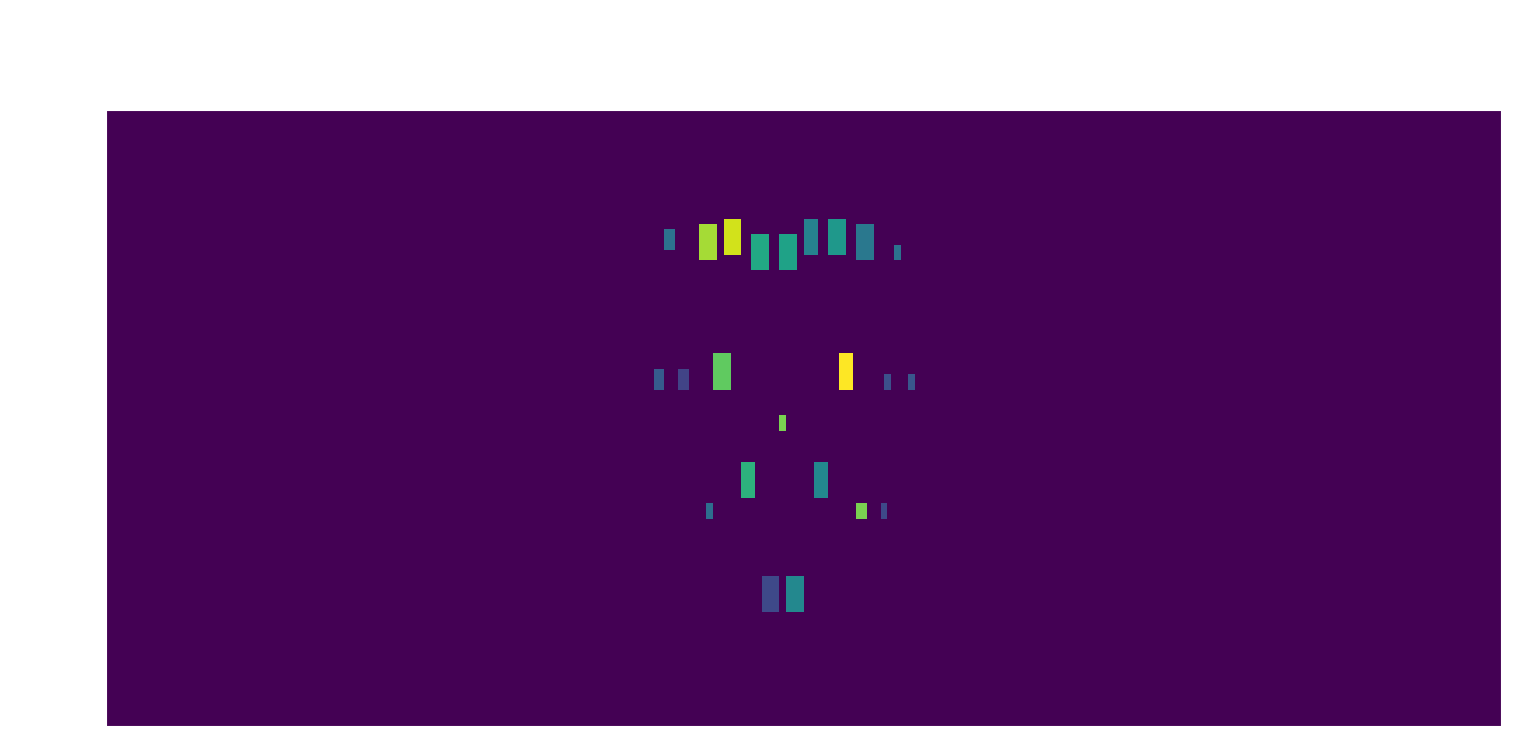

In [12]:
data_matrix = Y_df.to_numpy()
title = 'Развернутая карта дефектов файл 2' 
xlabel = 'Номер датчика'
ylabel = 'Номер измерения'
shift = 200

with plt.style.context('dark_background'):
        fig, ax = plt.subplots()
        
        fig.set_figwidth(18)
        fig.set_figheight(8)

        data_matrix = np.roll(Y_df.to_numpy(), shift, axis=1)
        ax.pcolormesh(data_matrix)

        xticks_labels = np.arange(0, data_matrix.shape[1]+1, 40)
        yticks_labels = np.linspace(0, data_matrix.shape[0], 8).astype(int)
    
        ax.set_xticks(xticks_labels)
        ax.set_yticks(yticks_labels)

        ax.set_xticklabels(['200','240','280','320','360','400/0','40','80','120','160','199'])
    
        ax.invert_yaxis()

        ax.set_title(title, fontsize=25) 
        ax.set_xlabel(xlabel, fontsize=20) 
        ax.set_ylabel(ylabel, fontsize=20) 
    
        fig.patch.set_alpha(0.0)
          
        ax.tick_params(axis='both', which='both', labelsize = 20)
        
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')
        
plt.show()

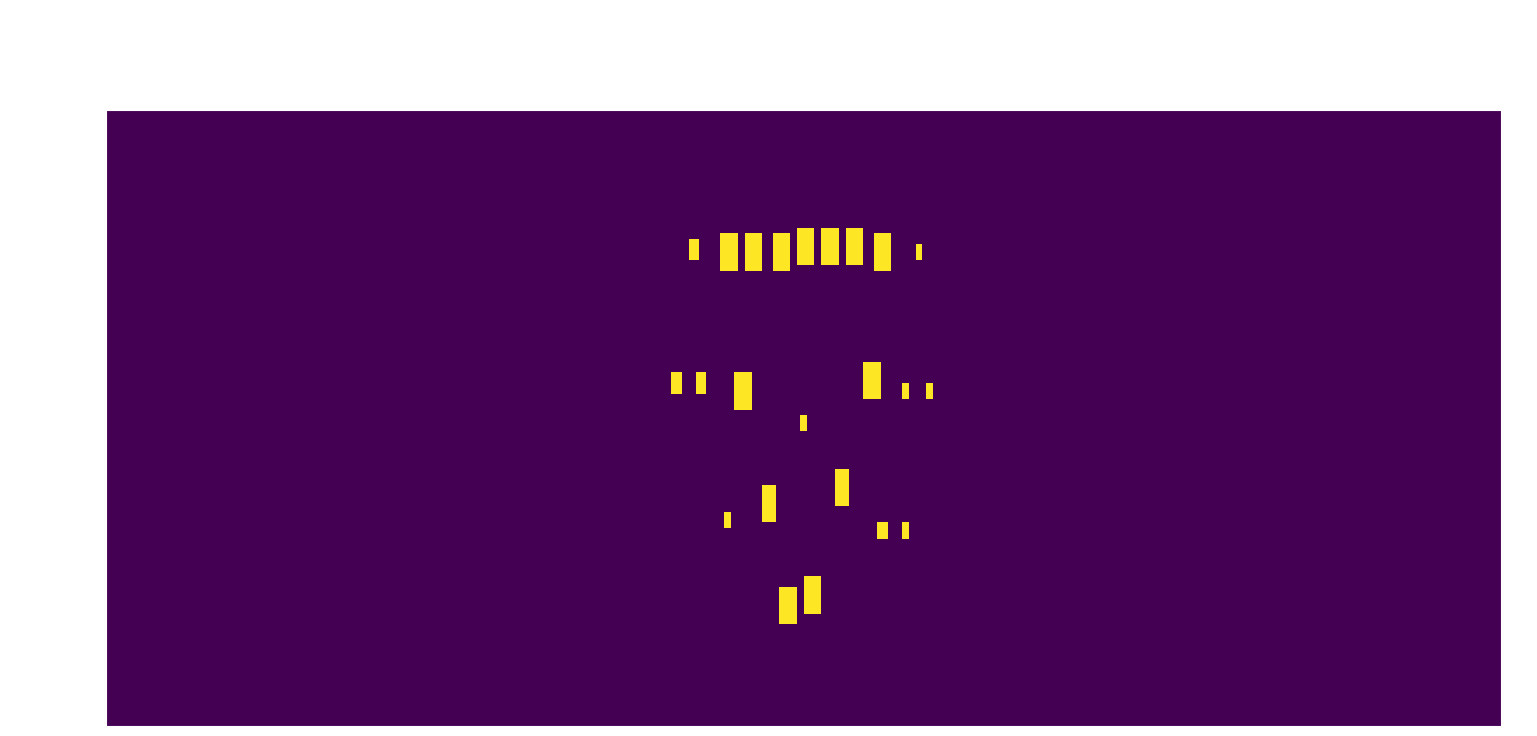

In [13]:
# draw a map from defects depths mask
#data_visual.draw_2D_map(Y_df.to_numpy(), 'Развернутая карта дефектов файл 2', 'Номер датчика', 'Номер измерения', 200)

# Запись данных в базу данных

In [11]:
# database connicting
conn = psycopg2.connect(database=db_name,
                        host=pg_host,
                        user=sql_user,
                        password=sql_pwd,
                        port=port)

In [12]:
# checking how many data tables have been downloaded to database
last_file_id = 0

with conn:
    with conn.cursor() as cursor:
        cursor.execute('SELECT MAX(file_id) FROM public.input_data_cell')
        result = cursor.fetchone()
        
if result[0] is not None: 
    last_file_id = result[0]

In [13]:
# insert data in input_data_cell table
for i in range(data_df.shape[0]):
    for j in range(data_df.shape[1]):
        with conn:
            with conn.cursor() as cursor:
                cursor.execute(INSERT_input_data_cell,
                                (last_file_id, # file id
                                i, # row id
                                j, # col id
                                list(data_df.iloc[i,j][:32]), # time_values list
                                list(data_df.iloc[i,j][32:])) # amplitude_values list
conn.commit()

In [ ]:
# insert data in output_data_cell table
for i in range(Y_df.shape[0]):
    for j in range(Y_df.shape[1]):
        with conn:
            with conn.cursor() as cursor:
                cursor.execute(INSERT_output_data_cell,
                                (last_file_id, # file id
                                i, # row id
                                j, # col id
                                bool(Y_df.iloc[i,j]), # defect_state
                                Y_df.iloc[i,j])) # defect_depth
conn.commit()

In [ ]:
# insert data in dataset_crop_description table
for i in range(data_df.shape[0] * data_df.shape[1]):
    with conn:
        with conn.cursor() as cursor:
            cursor.execute(INSERT_dataset_crop_description,
                            (last_file_id, # file id
                            i, # row id
                            j, # col id
                            False, # mirror_horizontal
                            False, # mirror_vertical
                            0, # rotation_90_degree_count
                            64, # crop_size
                            'test') # dataset_name
conn.commit()